# FRM Parte I, libro 4: Valoración y modelos de riesgo

| Caso | Tema del programa |
|---|---|
| 1 | Medidas de riesgo: VaR, Expected Shortfall y coherencia |
| 2 | Duración, convexidad, DV01 y duraciones parciales |
| 3 | Árboles binomiales y ejercicio anticipado |
| 4 | Black-Scholes-Merton, griegas y cobertura delta |
| 5 | Riesgo de crédito: pérdida esperada, Vasicek y matrices de transición |
| 6 | Riesgo operacional: distribución de pérdidas y método estándar |
| 7 | Pruebas de estrés con escenarios históricos chilenos |

## Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from dsaplicado import bcch, datos, frm, portafolio as pf, riesgo as rg, tasas
from dsaplicado.graficos import (AZUL_SECUENCIAL, COLORES, NEUTRO, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo,
                                 eje_porcentaje)

aplicar_estilo()
pd.set_option("display.float_format", "{:,.4f}".format)
RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "05_FRM" / "figuras"

precios = datos.cargar_precios(RAIZ / "datos" / "precios_ipsa.csv", {**datos.ACCIONES_IPSA, **datos.BENCHMARK_IPSA},
                               "2019-01-01", "2026-09-01").ffill()
retornos = pf.retornos_simples(precios).dropna()
cartera = retornos[list(datos.ACCIONES_IPSA.values())].mean(axis=1)
dolar = datos.cargar_indicador(RAIZ / "datos" / "dolar_historico.csv", "dolar", range(2000, 2027))
swap = bcch.cargar_series({}, None, None, RAIZ / "datos" / "bcch" / "swap_camara_pesos.csv").dropna() / 100
PLAZOS = np.array([float(c) for c in swap.columns])
ust_1a = datos.cargar_fred("DGS1", RAIZ / "datos" / "fred") / 100
hoy = swap.index[-1]

## Caso 1. VaR, Expected Shortfall y coherencia

**Concepto.** El VaR al nivel $\alpha$ es la pérdida que no se supera con probabilidad $\alpha$. El Expected Shortfall (ES) es la pérdida promedio cuando se supera el VaR. Con retornos normales:

$$\text{VaR}_\alpha = -\mu + z_\alpha\,\sigma, \qquad \text{ES}_\alpha = -\mu + \sigma\,\frac{\phi(z_\alpha)}{1 - \alpha}$$

Se calculan para una cartera de $1.000 millones invertida en las nueve acciones del IPSA.

In [2]:
valor = 1_000_000_000
mu, sigma = cartera.mean(), cartera.std()
gl, loc, escala = rg.ajustar_t(cartera)
simulados = stats.t.rvs(gl, loc, escala, size=200_000, random_state=0)
tabla = pd.DataFrame({
    "Normal": [rg.var_normal(mu, sigma, 0.99), rg.es_normal(mu, sigma, 0.975)],
    "Histórico": [rg.var_historico(cartera, 0.99), rg.es_historico(cartera, 0.975)],
    "Monte Carlo con t de Student": [rg.var_historico(simulados, 0.99), rg.es_historico(simulados, 0.975)],
}, index=["VaR 99% a 1 día", "ES 97,5% a 1 día"]).T
tabla["VaR 99% a 10 días, raíz del tiempo"] = tabla["VaR 99% a 1 día"] * np.sqrt(10)
(tabla * valor / 1e6).style.format("{:,.1f}").set_caption("Millones de pesos sobre una cartera de $1.000 millones")

,VaR 99% a 1 día,"ES 97,5% a 1 día","VaR 99% a 10 días, raíz del tiempo"
Normal,32.9,33.0,103.9
Histórico,35.4,39.9,111.8
Monte Carlo con t de Student,37.1,40.0,117.5


**Coherencia.** Una medida de riesgo coherente cumple cuatro propiedades: monotonía, invariancia a traslaciones, homogeneidad y subaditividad, es decir, el riesgo de una cartera no supera la suma de los riesgos de sus partes. El VaR puede violar la subaditividad; el ES no.

Contraejemplo clásico: dos bonos independientes, cada uno con 4% de probabilidad de incumplir y pérdida de 100 si incumple.

In [3]:
pd_bono, perdida = 0.04, 100
prob_alguno = 1 - (1 - pd_bono) ** 2
var_individual = 0 if pd_bono < 0.05 else perdida          # al 95%, un 4% de probabilidad no alcanza
var_cartera = perdida if prob_alguno > 0.05 else 0
es_individual = pd_bono * perdida / 0.05
prob = {0: (1 - pd_bono) ** 2, 100: 2 * pd_bono * (1 - pd_bono), 200: pd_bono**2}
cola, restante = 0.0, 0.05
for perdida_k in sorted(prob, reverse=True):
    tomado = min(prob[perdida_k], restante)
    cola += tomado * perdida_k
    restante -= tomado
es_cartera = cola / 0.05
pd.DataFrame({"cada bono": [var_individual, es_individual], "suma de los dos": [2 * var_individual, 2 * es_individual],
              "cartera con ambos": [var_cartera, es_cartera]}, index=["VaR 95%", "ES 95%"])

,cada bono,suma de los dos,cartera con ambos
VaR 95%,0.0000,0.0000,100.0000
ES 95%,80.0000,160.0000,103.2000


**Lectura.**

- **Los métodos que capturan colas pesadas dan un VaR mayor.** La normal da $33 millones al 99% a un día; la simulación histórica, $35 millones, y Monte Carlo con t de Student, $37 millones.
- **El ES al 97,5% queda cerca del VaR al 99%,** por diseño: Basilea eligió ese nivel para que el cambio de medida no alterara mucho el capital con retornos normales. Con colas pesadas, el ES sube más.
- **El VaR viola la subaditividad en el contraejemplo.** Cada bono por separado tiene un VaR al 95% de cero, pero la cartera con ambos tiene un VaR de 100: diversificar parece aumentar el riesgo. El ES de la cartera, 103, sí queda bajo la suma de los ES individuales, 160.

**Para el examen.**

- La regla de la raíz del tiempo supone retornos independientes e idénticamente distribuidos, y media cero.
- Basilea III reemplazó el VaR al 99% por el ES al 97,5% para el riesgo de mercado de la cartera de negociación.
- Métodos: paramétrico o delta-normal, simulación histórica, y Monte Carlo. Para opciones, el método delta-normal es inadecuado porque su valor no es lineal; se usa delta-gamma o revaluación completa.

## Caso 2. Duración, convexidad, DV01 y duraciones parciales

**Concepto.**

$$\frac{\Delta P}{P} \approx -D\,\Delta y + \tfrac{1}{2}\,C\,(\Delta y)^2, \qquad \text{DV01} = D \cdot P \cdot 0{,}0001$$

Para cubrir un bono con otro se iguala su DV01. Pero esa cobertura solo protege ante movimientos paralelos: si la curva cambia de forma, las duraciones parciales, o key rate durations, muestran qué tramo de la curva sigue expuesto.

Un banco tiene un bono a 10 años y lo cubre vendiendo un bono a 2 años, ambos con cupón de 6% y valorados con la curva swap de hoy.

In [4]:
cero_hoy = np.log1p(swap.iloc[-1].to_numpy())
curva = lambda t, desplazamiento=0.0: np.interp(t, PLAZOS, cero_hoy + desplazamiento)
bonos = {}
for nombre, plazo in [("Bono a 10 años", 10), ("Bono a 2 años", 2)]:
    t, m = tasas.flujos_bono(6, plazo)
    medidas = tasas.duracion_convexidad(t, m, curva(t) * 100)
    medidas["DV01"] = tasas.precio_con_curva(t, m, curva(t) * 100) - tasas.precio_con_curva(t, m, (curva(t) + 0.0001) * 100)
    bonos[nombre] = {**medidas, "tiempos": t, "montos": m}
tabla_bonos = pd.DataFrame({n: {k: v for k, v in b.items() if k not in ("tiempos", "montos")} for n, b in bonos.items()}).T
nominal_10a = 1_000_000_000
razon = tabla_bonos.loc["Bono a 10 años", "DV01"] / tabla_bonos.loc["Bono a 2 años", "DV01"]
print(f"Para cubrir $1.000 millones nominales del bono a 10 años se venden ${razon * nominal_10a:,.0f} del bono a 2 años")
tabla_bonos

Para cubrir $1.000 millones nominales del bono a 10 años se venden $4,008,617,149 del bono a 2 años


,precio,duracion,convexidad,DV01
Bono a 10 años,101.9829,7.6619,69.1041,0.0781
Bono a 2 años,101.7578,1.9149,3.7595,0.0195


In [5]:
NODOS = [1, 2, 5, 10]

def forma_nodo(k, t):
    # Forma triangular estándar: 1 en el nodo k, 0 en los nodos vecinos; plana antes del primero y después del último.
    x = np.array(NODOS, dtype=float)
    y = np.zeros(len(NODOS))
    y[k] = 1.0
    return np.interp(t, x, y)

def dv01_parciales(t, m):
    base = tasas.precio_con_curva(t, m, curva(t) * 100)
    return [base - tasas.precio_con_curva(t, m, (curva(t) + 0.0001 * forma_nodo(k, t)) * 100) for k in range(len(NODOS))]

parciales = pd.DataFrame({n: dv01_parciales(b["tiempos"], b["montos"]) for n, b in bonos.items()},
                         index=[f"nodo {n} años" for n in NODOS])
parciales["cartera cubierta"] = (parciales["Bono a 10 años"] * nominal_10a / 100
                                 - parciales["Bono a 2 años"] * razon * nominal_10a / 100)
print(f"Suma de los DV01 parciales de la cartera cubierta: ${parciales['cartera cubierta'].sum():,.0f} por punto base")
parciales.style.format({"Bono a 10 años": "{:.4f}", "Bono a 2 años": "{:.4f}", "cartera cubierta": "{:,.0f}"})

Suma de los DV01 parciales de la cartera cubierta: $21 por punto base


,Bono a 10 años,Bono a 2 años,cartera cubierta
nodo 1 años,0.0006,0.0006,"-19,321"
nodo 2 años,0.0028,0.0188,"-727,757"
nodo 5 años,0.0097,0.0000,"97,499"
nodo 10 años,0.0650,0.0000,"649,600"


**Lectura.**

- **El bono a 10 años tiene cuatro veces el DV01 del bono a 2 años.** Para cubrir $1.000 millones nominales del primero hay que vender $4.009 millones del segundo.
- **La cartera queda neutral ante movimientos paralelos:** la suma de sus DV01 parciales es prácticamente cero.
- **Pero sigue expuesta a cambios de pendiente.** Pierde unos $650.000 por cada punto base que sube la tasa a 10 años y gana unos $728.000 por cada punto base que sube la tasa a 2 años. Un empinamiento de la curva le genera pérdidas aunque la cobertura por DV01 sea perfecta.

**Para el examen.**

- La duración de Macaulay es el plazo promedio ponderado de los flujos; la modificada es la de Macaulay dividida por $(1 + y/m)$ y mide la sensibilidad del precio.
- La convexidad siempre favorece al tenedor de un bono sin opciones: cuando las tasas bajan el precio sube más, y cuando suben baja menos, de lo que predice la duración.
- La duración de una cartera es el promedio de las duraciones ponderado por valor de mercado.
- Los bonos con opción de rescate y los MBS pueden tener convexidad negativa.

## Caso 3. Árboles binomiales y ejercicio anticipado

**Concepto.** En el árbol de Cox, Ross y Rubinstein, el precio sube por $u = e^{\sigma\sqrt{\Delta t}}$ o baja por $d = 1/u$, con probabilidad neutral al riesgo $p = (e^{r\Delta t} - d)/(u - d)$. Se valora hacia atrás, y en una opción americana se compara en cada nodo el valor de mantenerla con el de ejercerla.

Se valora una put a un año sobre el ETF IPSA, con precio de ejercicio igual al actual.

ETF IPSA 5,035, volatilidad 21.6%, tasa 4.67%. Put europea con Black-Scholes: 318.92


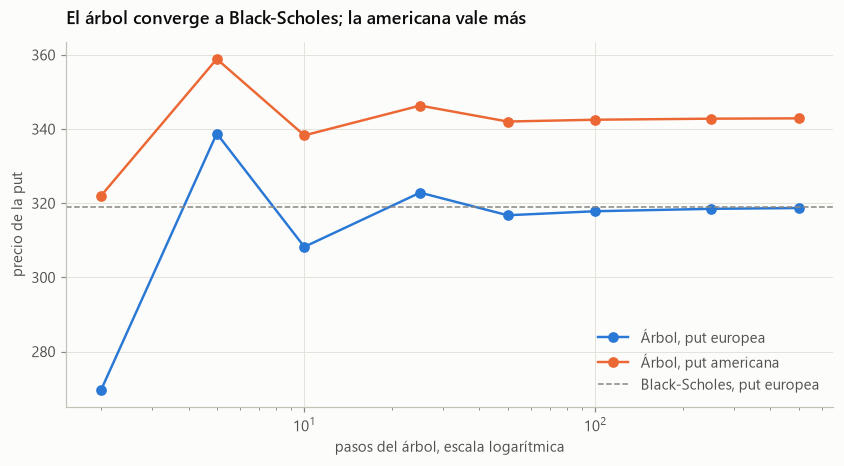

Prima por ejercicio anticipado con 500 pasos: 24.19


In [6]:
s_etf = precios["ETF IPSA"].iloc[-1]
vol_etf = np.log(precios["ETF IPSA"]).diff().std() * np.sqrt(252)
r_clp = np.log1p(swap["1"].iloc[-1])
europea_bsm = frm.black_scholes(s_etf, s_etf, r_clp, vol_etf, 1, "put")
pasos = [2, 5, 10, 25, 50, 100, 250, 500]
convergencia = pd.DataFrame({
    "put europea": [frm.arbol_binomial(s_etf, s_etf, r_clp, vol_etf, 1, n, "put", americana=False) for n in pasos],
    "put americana": [frm.arbol_binomial(s_etf, s_etf, r_clp, vol_etf, 1, n, "put", americana=True) for n in pasos],
}, index=pd.Index(pasos, name="pasos"))
print(f"ETF IPSA {s_etf:,.0f}, volatilidad {vol_etf:.1%}, tasa {r_clp:.2%}. Put europea con Black-Scholes: {europea_bsm:,.2f}")

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(convergencia.index, convergencia["put europea"], marker="o", color=COLORES[0], label="Árbol, put europea")
ax.plot(convergencia.index, convergencia["put americana"], marker="o", color=COLORES[1], label="Árbol, put americana")
ax.axhline(europea_bsm, color=TINTA_TENUE, linestyle="--", linewidth=1, label="Black-Scholes, put europea")
ax.set_xscale("log")
ax.set_xlabel("pasos del árbol, escala logarítmica")
ax.set_ylabel("precio de la put")
ax.set_title("El árbol converge a Black-Scholes; la americana vale más")
ax.legend(loc="lower right")
plt.show()
print(f"Prima por ejercicio anticipado con 500 pasos: {convergencia['put americana'].iloc[-1] - convergencia['put europea'].iloc[-1]:,.2f}")

**Lectura.** Con pocos pasos, el árbol oscila alrededor del precio correcto; desde unos 50 pasos se estabiliza y con 500 coincide con Black-Scholes. La put americana vale unos 24 puntos más que la europea: poder ejercerla antes tiene valor, porque si el ETF cae mucho conviene recibir el precio de ejercicio de inmediato y ganar intereses sobre él.

**Para el examen.**

- En un paso: $f = e^{-r\Delta t}[p f_u + (1-p) f_d]$. La valoración neutral al riesgo no usa el retorno esperado real del activo.
- Con dividendo continuo $q$, $p = (e^{(r-q)\Delta t} - d)/(u - d)$; para divisas, $q$ es la tasa extranjera; para futuros, $p = (1 - d)/(u - d)$.
- La delta en un nodo es $(f_u - f_d)/(S_u - S_d)$.

## Caso 4. Black-Scholes-Merton, griegas y cobertura delta

**Concepto.** Para una call europea sobre divisas, el modelo de Garman-Kohlhagen da

$$c = S e^{-r_f T} N(d_1) - K e^{-rT} N(d_2)$$

Las griegas miden la sensibilidad del precio. Quien vende una opción puede cubrirse manteniendo delta unidades del subyacente y ajustándolas cada día.

In [7]:
s0 = dolar.loc[:hoy].iloc[-1]
r_clp3, r_usd = np.log1p(swap["0.25"].iloc[-1]), np.log1p(ust_1a.iloc[-1])
vol_usd = np.log(dolar).diff().loc["2025":].std() * np.sqrt(252)
filas = {}
for k in [round(s0 * 0.95), round(s0), round(s0 * 1.05)]:
    filas[f"call con strike {k}"] = {"precio": frm.black_scholes(s0, k, r_clp3, vol_usd, 0.25, "call", q=r_usd),
                                      **frm.griegas(s0, k, r_clp3, vol_usd, 0.25, "call", q=r_usd)}
griegas = pd.DataFrame(filas).T
griegas["vega por punto de volatilidad"] = griegas["vega"] * 0.01
griegas["theta por día"] = griegas["theta"] / 365
print(f"Dólar {s0:.2f}, volatilidad {vol_usd:.1%}, opciones a tres meses")
griegas[["precio", "delta", "gamma", "vega por punto de volatilidad", "theta por día"]]

Dólar 945.87, volatilidad 10.8%, opciones a tres meses


,precio,delta,gamma,vega por punto de volatilidad,theta por día
call con strike 899,51.0292,0.8262,0.0048,1.1596,-0.0637
call con strike 946,20.0934,0.5055,0.0078,1.8654,-0.1085
call con strike 993,5.1694,0.1890,0.0053,1.2740,-0.0748


In [8]:
# Cobertura delta con trayectorias reales: se vende una call a tres meses al inicio de cada trimestre desde 2010.
serie = dolar.loc["2010":].copy()
tasa_clp = np.log1p(swap["0.25"]).reindex(serie.index).ffill()
tasa_usd = np.log1p(ust_1a).reindex(serie.index).ffill()
resultados = []
inicios = range(63, len(serie) - 63, 63)
for i in inicios:
    tramo = serie.iloc[i:i + 64]
    sigma_ = np.log(serie.iloc[i - 63:i + 1]).diff().std() * np.sqrt(252)
    rc, ru = tasa_clp.iloc[i], tasa_usd.iloc[i]
    k, dt = tramo.iloc[0], 1 / 252
    prima = frm.black_scholes(tramo.iloc[0], k, rc, sigma_, 0.25, "call", q=ru)
    delta = frm.griegas(tramo.iloc[0], k, rc, sigma_, 0.25, "call", q=ru)["delta"]
    caja = prima - delta * tramo.iloc[0]
    for j in range(1, len(tramo)):
        caja *= np.exp(rc * dt)
        restante = max(0.25 - j * dt, 1e-6)
        nuevo_delta = frm.griegas(tramo.iloc[j], k, rc, sigma_, restante, "call", q=ru)["delta"] if j < len(tramo) - 1 else float(tramo.iloc[j] > k)
        caja += delta * tramo.iloc[j] * (np.exp(ru * dt) - 1)          # interés en dólares sobre la posición
        caja -= (nuevo_delta - delta) * tramo.iloc[j]
        delta = nuevo_delta
    pago = max(tramo.iloc[-1] - k, 0)
    cubierta = caja + delta * tramo.iloc[-1] - pago
    descubierta = prima * np.exp(rc * 0.25) - pago
    resultados.append({"inicio": tramo.index[0], "cubierta": cubierta / prima, "descubierta": descubierta / prima})
cobertura = pd.DataFrame(resultados).set_index("inicio")
pd.DataFrame({"promedio": cobertura.mean(), "desviación estándar": cobertura.std(), "peor caso": cobertura.min()}).style.format("{:.1%}").set_caption(
    f"Resultado del vendedor como % de la prima, {len(cobertura)} trimestres")

,promedio,desviación estándar,peor caso
cubierta,3.2%,20.6%,-64.2%
descubierta,-22.5%,168.2%,-586.7%


**Lectura.**

- **Las griegas siguen el patrón teórico.** La call en el dinero tiene delta cercana a 0,5 y la mayor gamma, vega y theta; las calls lejos del dinero son menos sensibles.
- **La cobertura delta funciona con datos reales.** En 65 trimestres desde 2010, el vendedor sin cubrir tuvo un resultado con desviación estándar de 168% de la prima y un peor caso de -587%. Con cobertura delta diaria, la desviación cae a 21%.
- **La cobertura no es perfecta.** Queda un error por ajustar solo una vez al día y porque la volatilidad realizada difiere de la usada para valorar la opción. Es el riesgo de gamma y de vega que la delta no cubre.

**Para el examen.**

- Delta de una call entre 0 y 1; de una put, entre -1 y 0. Gamma y vega son iguales para una call y una put con los mismos parámetros, y máximas cerca del dinero.
- Una cartera neutral en delta sigue expuesta a gamma: si gamma es negativa, pierde con los movimientos grandes. Theta y gamma tienen signos opuestos.
- Para ser neutral en gamma se necesita otra opción, porque el subyacente tiene gamma cero.
- Supuestos de Black-Scholes: precio lognormal, volatilidad y tasa constantes, sin costos de transacción, sin dividendos y negociación continua.

## Caso 5. Riesgo de crédito

**Concepto.** La pérdida esperada es $EL = PD \times LGD \times EAD$. El capital cubre la pérdida inesperada. La fórmula de Basilea para bancos que usan modelos internos parte del modelo de Vasicek, que da la tasa de incumplimiento en el peor caso con confianza $X$:

$$WCDR = N\!\left(\frac{N^{-1}(PD) + \sqrt{\rho}\,N^{-1}(X)}{\sqrt{1 - \rho}}\right), \qquad K \approx LGD \times (WCDR - PD)$$

donde $\rho$ es la correlación de los deudores con un factor común de la economía.

In [9]:
cartera_credito = pd.DataFrame({
    "segmento": ["Hipotecario", "Consumo", "Pymes", "Grandes empresas"],
    "EAD": [40_000, 15_000, 20_000, 25_000], "PD": [0.01, 0.05, 0.03, 0.005], "LGD": [0.20, 0.70, 0.45, 0.40],
    "correlación": [0.15, 0.04, 0.12, 0.20],
}).set_index("segmento")   # montos en millones de pesos; parámetros ilustrativos
cartera_credito["pérdida esperada"] = frm.perdida_esperada(cartera_credito["PD"], cartera_credito["LGD"], cartera_credito["EAD"])
cartera_credito["WCDR 99,9%"] = [frm.tasa_default_peor_caso(p, c) for p, c in zip(cartera_credito["PD"], cartera_credito["correlación"])]
cartera_credito["capital"] = cartera_credito["EAD"] * cartera_credito["LGD"] * (cartera_credito["WCDR 99,9%"] - cartera_credito["PD"])
cartera_credito["capital / EAD"] = cartera_credito["capital"] / cartera_credito["EAD"]
cartera_credito.style.format({"EAD": "{:,.0f}", "PD": "{:.1%}", "LGD": "{:.0%}", "correlación": "{:.2f}",
                              "pérdida esperada": "{:,.0f}", "WCDR 99,9%": "{:.1%}", "capital": "{:,.0f}", "capital / EAD": "{:.1%}"})

,EAD,PD,LGD,correlación,pérdida esperada,"WCDR 99,9%",capital,capital / EAD
segmento,,,,,,,,
Hipotecario,"40,000",1.0%,20%,0.15,80,11.0%,802,2.0%
Consumo,"15,000",5.0%,70%,0.04,525,14.7%,"1,022",6.8%
Pymes,"20,000",3.0%,45%,0.12,270,19.4%,"1,475",7.4%
Grandes empresas,"25,000",0.5%,40%,0.20,50,9.1%,860,3.4%


In [10]:
calificaciones = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC", "D"]
transicion = pd.DataFrame([
    [90.81, 8.33, 0.68, 0.06, 0.12, 0.00, 0.00, 0.00],
    [0.70, 90.65, 7.79, 0.64, 0.06, 0.14, 0.02, 0.00],
    [0.09, 2.27, 91.05, 5.52, 0.74, 0.26, 0.01, 0.06],
    [0.02, 0.33, 5.95, 86.93, 5.30, 1.17, 0.12, 0.18],
    [0.03, 0.14, 0.67, 7.73, 80.53, 8.84, 1.00, 1.06],
    [0.00, 0.11, 0.24, 0.43, 6.48, 83.46, 4.07, 5.20],
    [0.22, 0.00, 0.22, 1.30, 2.38, 11.24, 64.86, 19.79],
    [0, 0, 0, 0, 0, 0, 0, 100],
], index=calificaciones, columns=calificaciones)
transicion = transicion.div(transicion.sum(axis=1), axis=0)
acumulada = pd.DataFrame({anios: frm.transicion_multiperiodo(transicion, anios)["D"] for anios in [1, 3, 5, 10]})
acumulada.columns = [f"{a} años" for a in acumulada.columns]
acumulada.drop(index="D").style.format("{:.2%}").set_caption("Probabilidad acumulada de incumplimiento según la calificación inicial")

,1 años,3 años,5 años,10 años
AAA,0.00%,0.01%,0.04%,0.29%
AA,0.00%,0.05%,0.18%,0.92%
A,0.06%,0.27%,0.64%,2.40%
BBB,0.18%,0.91%,2.10%,6.61%
BB,1.06%,4.43%,8.67%,19.67%
B,5.20%,15.42%,24.41%,40.89%
CCC,19.79%,42.58%,54.16%,66.83%


**Lectura.**

- **La pérdida esperada y el capital miden cosas distintas.** Consumo tiene la mayor pérdida esperada, $525 millones, por su alta PD y LGD. Pero pymes exige más capital por peso prestado, 7,4%, porque combina una PD relevante con una correlación con el ciclo tres veces mayor que la de consumo.
- **La correlación pesa mucho.** Los créditos a grandes empresas tienen una PD de solo 0,5%, pero con una correlación de 0,20 su tasa de incumplimiento en el peor caso llega a 9,1%.
- **El riesgo de incumplimiento crece con el plazo y cae con la calificación.** Con la matriz clásica del documento técnico de CreditMetrics (J.P. Morgan, 1997), un emisor BBB tiene 0,2% de probabilidad de incumplir en un año y 6,6% en diez; uno B, 5,2% y 41%. La multiplicación de matrices supone que las transiciones no dependen de la historia, lo que en la práctica no se cumple: las bajas de calificación tienden a seguir bajando.

**Para el examen.**

- La LGD es uno menos la tasa de recuperación, y la recuperación depende de la prelación de la deuda y de las garantías.
- La pérdida inesperada de un préstamo con LGD fija es $EAD \times LGD \times \sqrt{PD(1-PD)}$. En una cartera, la diversificación reduce la pérdida inesperada pero no la esperada.
- Las probabilidades de incumplimiento neutrales al riesgo, que se derivan de los spreads, son mayores que las del mundo real porque incluyen primas por riesgo y liquidez.
- Las calificaciones de agencias miran a través del ciclo y cambian lentamente; las basadas en mercado, como el modelo de Merton, reaccionan de inmediato.

## Caso 6. Riesgo operacional

**Concepto.** El enfoque de distribución de pérdidas (LDA) combina una frecuencia de eventos, típicamente Poisson, con una severidad de cola pesada, típicamente lognormal. El capital es el percentil 99,9% de la pérdida anual menos la pérdida esperada.

Basilea III reemplazó los modelos internos por un método estándar basado en el indicador de negocio (BI), con coeficientes marginales de 12%, 15% y 18% según su tamaño.

Pérdida anual esperada: $2,524 millones
Percentil 99,9%: $27,145 millones. Capital por pérdida inesperada: $24,621 millones


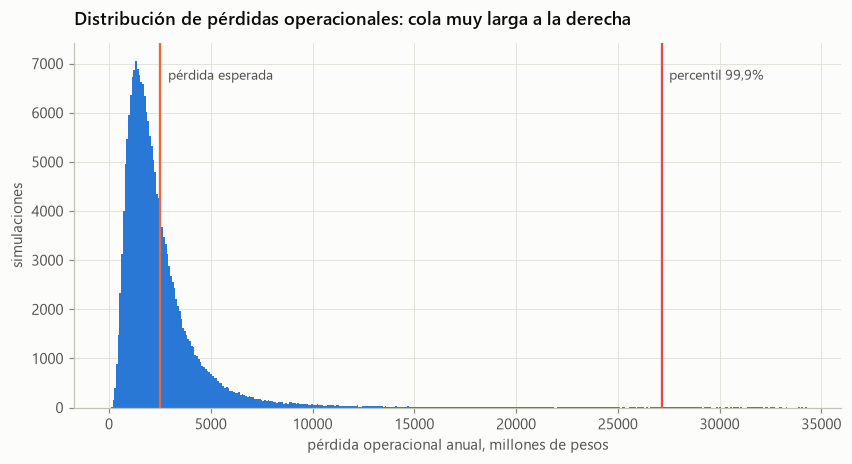

,"BIC, millones de euros"
"indicador de negocio, millones de euros",
800,96.0000
5000,720.0000
40000,"6,270.0000"


In [11]:
frecuencia, mu_log, sigma_log = 25, np.log(20), 1.8     # 25 eventos al año; mediana de $20 millones por evento
perdidas = frm.perdidas_operacionales(frecuencia, mu_log, sigma_log, simulaciones=200_000)
esperada, p999 = perdidas.mean(), np.percentile(perdidas, 99.9)
print(f"Pérdida anual esperada: ${esperada:,.0f} millones")
print(f"Percentil 99,9%: ${p999:,.0f} millones. Capital por pérdida inesperada: ${p999 - esperada:,.0f} millones")

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.hist(perdidas, bins=400, color=COLORES[0], range=(0, np.percentile(perdidas, 99.95)))
for valor_, nombre, color in [(esperada, "pérdida esperada", COLORES[1]), (p999, "percentil 99,9%", COLORES[7])]:
    ax.axvline(valor_, color=color, linewidth=1.5)
    ax.annotate(nombre, (valor_, ax.get_ylim()[1] * 0.9), xytext=(5, 0), textcoords="offset points", fontsize=9, color=TINTA_SECUNDARIA)
ax.set_xlabel("pérdida operacional anual, millones de pesos")
ax.set_ylabel("simulaciones")
ax.set_title("Distribución de pérdidas operacionales: cola muy larga a la derecha")
plt.show()

indicador = pd.Series({bi: frm.componente_indicador_negocio(bi) for bi in [800, 5_000, 40_000]}, name="BIC, millones de euros")
indicador.index.name = "indicador de negocio, millones de euros"
indicador.to_frame()

**Lectura.** La pérdida anual esperada es de unos $2.500 millones, pero el percentil 99,9% llega a $27.000 millones, más de diez veces más. Esa distancia es la cola pesada: el capital no lo determinan los eventos frecuentes y chicos, sino los raros y enormes. En el método estándar, el BIC crece más que proporcionalmente con el tamaño del banco: 12% del indicador de negocio en uno chico y cerca de 16% en uno de 40.000 millones de euros.

**Para el examen.**

- Las siete categorías de eventos de Basilea: fraude interno, fraude externo, prácticas laborales, clientes y productos, daños a activos físicos, interrupción del negocio y fallas de sistemas, y ejecución y gestión de procesos.
- En el método estándar, el capital es el BIC multiplicado por el multiplicador de pérdidas internas (ILM), que depende de las pérdidas históricas del banco.
- La severidad se modela con distribuciones de cola pesada; la teoría de valores extremos se usa para la cola.

## Caso 7. Pruebas de estrés con escenarios históricos chilenos

**Concepto.** Una prueba de estrés aplica a la cartera actual los movimientos de un episodio extremo, sin asignarle una probabilidad. Complementa al VaR, que mira el comportamiento típico.

La cartera de un banco tiene $10.000 millones en acciones del IPSA, una posición larga de US$5 millones y una exposición a tasas con DV01 de $20 millones: pierde $20 millones por cada punto base que sube la tasa swap a 5 años.

In [12]:
nivel_acciones = (1 + cartera).cumprod()
escenarios = {"Estallido social": ("2019-10-17", "2019-11-28"), "Pandemia": ("2020-02-21", "2020-03-23"),
              "Alza de la TPM": ("2021-06-30", "2022-10-31"), "Aranceles de Estados Unidos": ("2025-04-02", "2025-04-09")}
exposicion = {"acciones": 10_000_000_000, "dolares": 5_000_000, "dv01": 20_000_000}
filas = {}
for nombre, (inicio, fin) in escenarios.items():
    acciones_cambio = nivel_acciones.asof(pd.Timestamp(fin)) / nivel_acciones.asof(pd.Timestamp(inicio)) - 1
    # El dólar observado refleja el día hábil anterior: se usa el valor publicado el día siguiente a cada fecha.
    dolar_ini = dolar.loc[pd.Timestamp(inicio) + pd.Timedelta(days=1):].iloc[0]
    dolar_fin = dolar.loc[pd.Timestamp(fin) + pd.Timedelta(days=1):].iloc[0]
    tasa_cambio_pb = (swap["5"].asof(pd.Timestamp(fin)) - swap["5"].asof(pd.Timestamp(inicio))) * 10_000
    filas[nombre] = {
        "acciones": acciones_cambio, "dólar, pesos": dolar_fin - dolar_ini, "tasa 5 años, pb": tasa_cambio_pb,
        "resultado acciones": exposicion["acciones"] * acciones_cambio / 1e6,
        "resultado dólar": exposicion["dolares"] * (dolar_fin - dolar_ini) / 1e6,
        "resultado tasas": -exposicion["dv01"] * tasa_cambio_pb / 1e6,
    }
estres = pd.DataFrame(filas).T
estres["resultado total, millones"] = estres[["resultado acciones", "resultado dólar", "resultado tasas"]].sum(axis=1)
var_10d = rg.var_historico(cartera, 0.99) * np.sqrt(10) * exposicion["acciones"] / 1e6
print(f"Referencia: VaR histórico al 99% a 10 días de las acciones solas, ${var_10d:,.0f} millones")
estres.style.format({"acciones": "{:.1%}", "dólar, pesos": "{:+.0f}", "tasa 5 años, pb": "{:+.0f}",
                     "resultado acciones": "{:,.0f}", "resultado dólar": "{:,.0f}", "resultado tasas": "{:,.0f}",
                     "resultado total, millones": "{:,.0f}"})

Referencia: VaR histórico al 99% a 10 días de las acciones solas, $1,118 millones


,acciones,"dólar, pesos","tasa 5 años, pb",resultado acciones,resultado dólar,resultado tasas,"resultado total, millones"
Estallido social,-15.4%,+115,+33,"-1,536",575,-654,"-1,615"
Pandemia,-34.9%,+51,-11,"-3,488",256,228,"-3,003"
Alza de la TPM,9.7%,+209,+332,967,"1,043","-6,646","-4,636"
Aranceles de Estados Unidos,-2.8%,+50,-19,-275,251,386,361


**Lectura.**

- **Cada episodio golpea por un canal distinto.** En la pandemia dominó la caída de las acciones, de 35%. En el ciclo de alzas de la TPM, las acciones subieron, pero la tasa a 5 años subió 332 puntos base y la exposición a tasas perdió $6.646 millones.
- **La posición en dólares amortiguó los golpes.** En todos los escenarios el peso se depreció, así que la posición larga en dólares ganó. Es la correlación negativa entre acciones y dólar del libro 2 funcionando como cobertura natural.
- **Los escenarios superan con creces al VaR.** El peor, el ciclo de alzas, pierde $4.636 millones, cuatro veces el VaR a 10 días de las acciones. El VaR mide días normales; las pruebas de estrés, lo que puede pasar cuando todo sale mal.

**Para el examen.**

- Tipos de escenarios: históricos, hipotéticos y de estrés inverso, que buscan qué escenario haría quebrar al banco.
- Las pruebas de estrés deben considerar los efectos de segunda ronda, como la liquidez de los activos y el comportamiento de otros participantes.
- Los reguladores usan pruebas de estrés de todo el sistema para fijar exigencias de capital, como el CCAR en Estados Unidos.
- El gobierno de las pruebas de estrés exige la participación del directorio y de la alta gerencia, y documentación y revisión independiente.